In [1]:
import drizzlepac
from astropy.io import fits
from astropy.table import Table
from astroquery.mast import Observations
from stwcs.wcsutil import headerlet
from stwcs import updatewcs

import glob
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from stwcs.wcsutil import headerlet
from astropy.wcs import WCS
from astropy import units as u
import numpy as np

# See this notebook for reference
# https://spacetelescope.github.io/notebooks/notebooks/DrizzlePac/align_multiple_visits/align_multiple_visits.html



The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    
The following tasks in the drizzlepac package can be run with TEAL:
    astrodrizzle       config_testbed      imagefindpars           mapreg       
       photeq            pixreplace           pixtopix            pixtosky      
  refimagefindpars       resetbits          runastrodriz          skytopix      
     tweakback            tweakreg           updatenpol


# We will use TweakReg from DrizzlePac to align the WCS

In [2]:
coord0 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(u.hourangle, u.deg))
coord1 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(u.hourangle, u.deg))
coord2 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(u.hourangle, u.deg))

In [3]:
data_dir = "../data/SMACSJ0723/HST/"
flt_paths = glob.glob(data_dir + "*flt.fits")

filters = ["F105W", "F125W", "F160W"]

flt_paths_sorted = {
    "F160W": [p for p in flt_paths if "f160w" in p],
    "F125W": [p for p in flt_paths if "f125w" in p],
    "F105W": [p for p in flt_paths if "f160w" not in p and "f125w" not in p], # Both visits
    "F105W O1": [p for p in flt_paths if "f160w" not in p and "f125w" not in p and "za" in p], # first orbit (infered from the TIME-OBS and DATE-OBS keywords
    "F105W O2": [p for p in flt_paths if "f160w" not in p and "f125w" not in p and "bm" in p]  # second orbit
}

paths = flt_paths_sorted["F105W"]

In [4]:
paths

['../data/SMACSJ0723/HST/iczgzaj6q_flt.fits',
 '../data/SMACSJ0723/HST/iczgzbmmq_flt.fits',
 '../data/SMACSJ0723/HST/iczgzbmaq_flt.fits',
 '../data/SMACSJ0723/HST/iczgzbmbq_flt.fits',
 '../data/SMACSJ0723/HST/iczgzaj1q_flt.fits',
 '../data/SMACSJ0723/HST/iczgzaj4q_flt.fits',
 '../data/SMACSJ0723/HST/iczgzaj2q_flt.fits',
 '../data/SMACSJ0723/HST/iczgzbmgq_flt.fits']

# Exploration of the WCS in the flt files and the one currently in use

In [5]:
filename = paths[3]
fits.info(filename)

Filename: ../data/SMACSJ0723/HST/iczgzbmbq_flt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     270   ()      
  1  SCI           1 ImageHDU       171   (1014, 1014)   float32   
  2  ERR           1 ImageHDU        50   (1014, 1014)   float32   
  3  DQ            1 ImageHDU        42   (1014, 1014)   int16   
  4  SAMP          1 ImageHDU        36   (1014, 1014)   int16   
  5  TIME          1 ImageHDU        36   (1014, 1014)   float32   
  6  HDRLET        1 HeaderletHDU     17   ()      
  7  HDRLET        2 HeaderletHDU     17   ()      
  8  HDRLET        3 HeaderletHDU     17   ()      
  9  HDRLET        4 HeaderletHDU     17   ()      
 10  HDRLET        5 HeaderletHDU     17   ()      
 11  HDRLET        6 HeaderletHDU     17   ()      
 12  WCSCORR       1 BinTableHDU     59   7R x 24C   [40A, I, A, 24A, 24A, 24A, 24A, D, D, D, D, D, D, D, D, 24A, 24A, D, D, D, D, J, 40A, 128A]   
 13  HDRLET        7 HeaderletHDU     1

In [6]:
ext_indices = headerlet.find_headerlet_HDUs(filename, strict=False)

# To show it's consistent with the fits.info from above
print(ext_indices)

[6, 7, 8, 9, 10, 11, 13, 14]


In [7]:
hdu = fits.open(filename)
print('Ext\tWCSNAME')
for ext_ind in ext_indices:
    print(ext_ind, '\t', hdu[ext_ind].header['WCSNAME'])

hdu.close()

Ext	WCSNAME
6 	 OPUS
7 	 IDC_w3m18525i
8 	 IDC_w3m18525i-GSC240
9 	 IDC_w3m18525i-HSC30
10 	 IDC_w3m18525i-FIT_REL_GAIADR2
11 	 IDC_w3m18525i-FIT_SVM_GAIADR2
13 	 IDC_w3m18525i
14 	 IDC_w3m18525i-FIT_REL_GAIAeDR3


In [8]:
current_wcs = fits.getval(filename, 'WCSNAME', ext=('SCI', 1))

print(current_wcs)

IDC_w3m18525i-FIT_SVM_GAIADR2


Setting up logfile :  tweakreg.log
TweakReg Version 3.5.1 started at: 19:09:26.213 (26/08/2023) 

Version Information
--------------------
Python Version 3.10.11 | packaged by conda-forge | (main, May 10 2023, 18:58:44) [GCC 11.3.0]
numpy Version -> 1.24.3 
astropy Version -> 5.3 
stwcs Version -> 1.7.2 
photutils Version -> 1.8.0 

Restoring WCS solutions to original state using updatewcs...

AstrometryDB service available...


Deleted all instances of WCS with key A in extensions [1]
Wcskey 'O' is reserved for the original WCS and should not be deleted.
INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency

Replacing primary WCS with
	Headerlet with WCSNAME=IDC_w3m18525i-FIT_SVM_GAIADR2


Deleted all instances of WCS with key A in extensions [1]
Wcskey 'O' is reserved for the original WCS and should not be deleted.
INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency

Replacing primary WCS with
	Headerlet with WCSNAME=IDC_w3m18525i-FIT_SVM_GAIADR2


...

Replacing primary WCS with
	Headerlet with WCSNAME=IDC_w3m18525i-FIT_SVM_GAIADR2


Deleted all instances of WCS with key A in extensions [1]
Wcskey 'O' is reserved for the original WCS and should not be deleted.
INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency

Replacing primary WCS with
	Headerlet with WCSNAME=IDC_w3m18525i-FIT_SVM_GAIADR2


Deleted all instances of WCS with key A in extensions [1]
Wcskey 'O' is reserved for the original WCS and should not be deleted.
INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency

Replacing primary WCS with
	Headerlet with WCSNAME=IDC_w3m18525i-FIT_SVM_GAIADR2

Finding shifts for: 
    /home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzaj6q_flt.fits
    /home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzbmmq_flt.fits
    /home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzbmaq_flt.fits
    /home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzbmbq_flt.fits
    /home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzaj1q_flt.fits
    /home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzaj4q_flt.fits
    /home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzaj2q_flt.fits
    /home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzbmgq_flt.fits

===  Source finding for image '/home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzaj6q_flt.fits':
  #  Source 

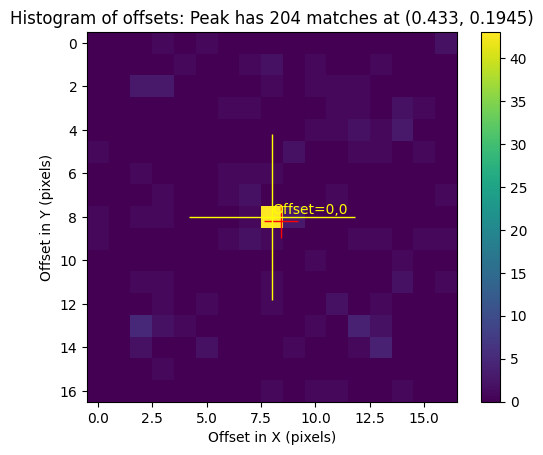

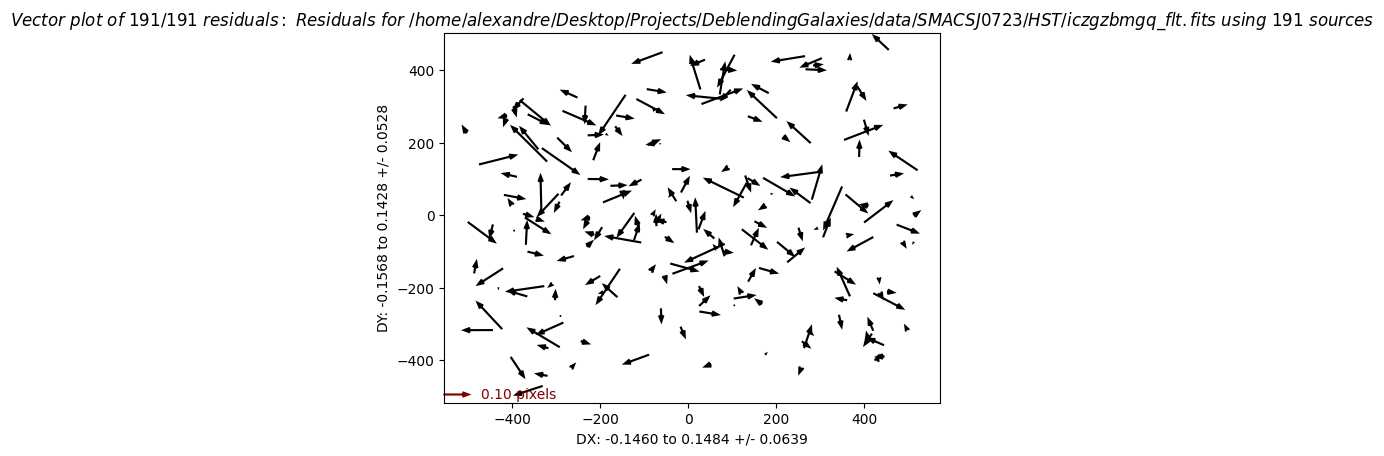

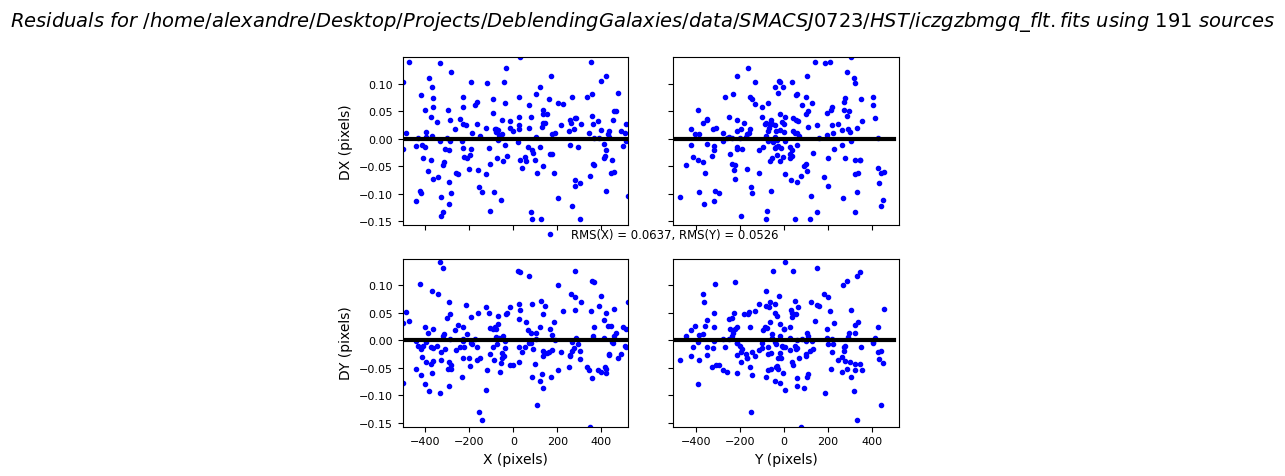

In [9]:
import os
# Make sure to download the distortion model reference fild (idc extension) from https://hst-crds.stsci.edu/bestrefs/ and download the folder pointed by iref
os.environ['iref'] = '../data/SMACSJ0723/HST/' # folder where fits are (and idc table)

# Only update wcs once the solution make sense
drizzlepac.tweakreg.TweakReg(
    paths, 
    conv_width=3.5, 
    threshold=2, 
    #peakmax=None,
    #searchrad=1.0,
    #fitgeometry='rscale',
    updatewcs=True, 
    clean=True, 
    writecat=False, 
    interactive=False, 
    shiftfile=True)

In [10]:
shift_tab = Table.read('shifts.txt',
                       format='ascii.no_header',
                       names=['file','dx','dy','rot','scale','xrms','yrms'])

formats = ['.2f', '.2f', '.3f', '.5f', '.2f', '.2f']
for i, col in enumerate(shift_tab.colnames[1:]):
    shift_tab[col].format = formats[i]
shift_tab

file,dx,dy,rot,scale,xrms,yrms
str90,float64,float64,float64,float64,float64,float64
/home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzaj6q_flt.fits,0.00,0.00,0.000,1.00000,0.00,0.00
/home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzbmmq_flt.fits,-0.04,-0.01,0.007,1.00002,0.06,0.05
/home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzbmaq_flt.fits,-0.09,-0.04,0.006,1.00002,0.06,0.05
/home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzbmbq_flt.fits,-0.12,-0.02,0.004,1.00000,0.06,0.05
/home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzaj1q_flt.fits,0.03,0.02,360.000,1.00001,0.10,0.08
/home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzaj4q_flt.fits,-0.01,0.03,0.000,0.99999,0.04,0.07
/home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzaj2q_flt.fits,-0.01,-0.00,0.000,0.99999,0.08,0.05
/home/alexandre/Desktop/Projects/DeblendingGalaxies/data/SMACSJ0723/HST/iczgzbmgq_flt.fits,-0.04,0.01,0.005,0.99999,0.06,0.05


In [11]:
# Checking out the shift wcs, which 
tweakreg_data = fits.open("shifts_wcs.fits")

In [12]:
filename = paths[1]
hdu = fits.open(filename)
print('Ext\tWCSNAME')
for ext_ind in ext_indices:
    print(ext_ind, '\t', hdu[ext_ind].header['WCSNAME'])

hdu.close()

Ext	WCSNAME
6 	 OPUS
7 	 IDC_w3m18525i
8 	 IDC_w3m18525i-GSC240
9 	 IDC_w3m18525i-HSC30
10 	 IDC_w3m18525i-FIT_REL_GAIADR2
11 	 IDC_w3m18525i-FIT_SVM_GAIADR2
13 	 IDC_w3m18525i
14 	 IDC_w3m18525i-FIT_REL_GAIAeDR3


In [13]:
current_wcs = fits.getval(filename, 'WCSNAME', ext=('SCI', 1))

print(current_wcs)

IDC_w3m18525i-FIT_SVM_GAIADR2


In [14]:
data = fits.open(paths[0])
wcs = WCS(data["SCI"].header, data)
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 110.83027453989  -73.454186823793  
CRPIX : 507.0  507.0  
CD1_1 CD1_2  : -2.9450788540931e-05  2.0810315525721e-05  
CD2_1 CD2_2  : 2.3393459168316e-05  2.6373159106492e-05  
NAXIS : 1014  1014

In [15]:
WCS(tweakreg_data[1].header)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 110.83230935345  -73.454147588231  
CRPIX : 579.5  527.5  
PC1_1 PC1_2  : -2.7835848824446e-05  2.2232998040008e-05  
PC2_1 PC2_2  : 2.2232998040008e-05  2.7835848824446e-05  
CDELT : 1.0  1.0  
NAXIS : 0  0

# Check if alignment is correct with Gaia catalog

In [31]:
from drizzlepac.align import generate_astrometric_catalog
from astropy.visualization import PercentileInterval, ImageNormalize, LogStretch

2023238191327 INFO src=drizzlepac.haputils.astrometric_utils- Created catalog 'ref_cat.ecsv' with 38  sources
2023238191327 INFO src=drizzlepac.align- Wrote reference catalog refcatalog.cat.


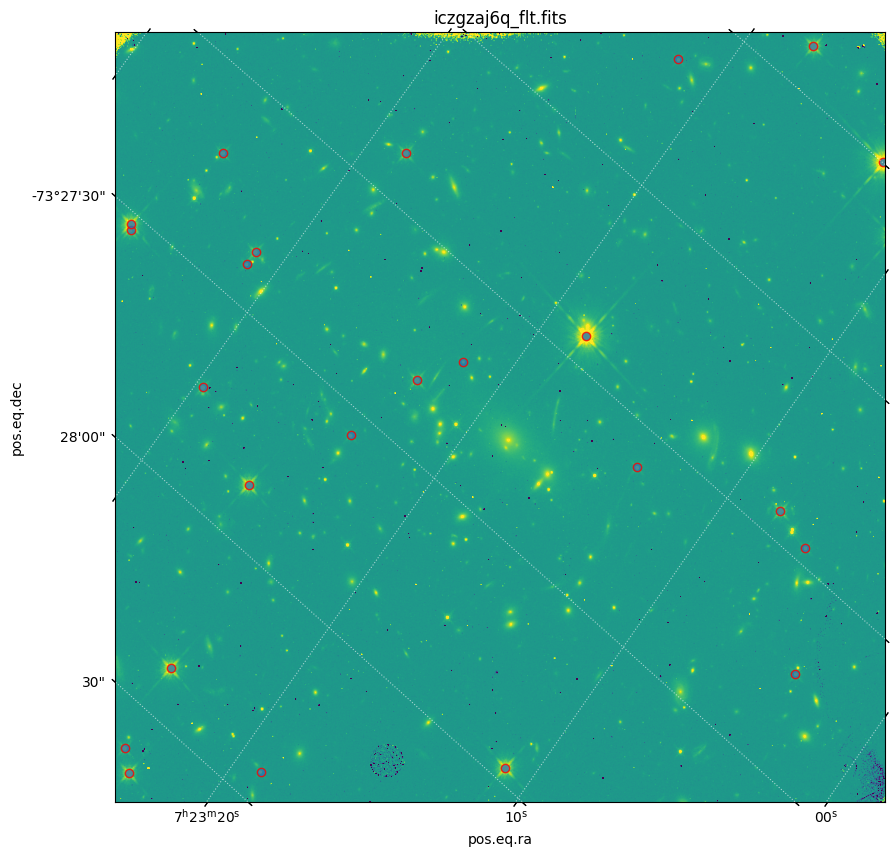

2023238191328 INFO src=drizzlepac.haputils.astrometric_utils- Created catalog 'ref_cat.ecsv' with 38  sources
2023238191328 INFO src=drizzlepac.align- Wrote reference catalog refcatalog.cat.


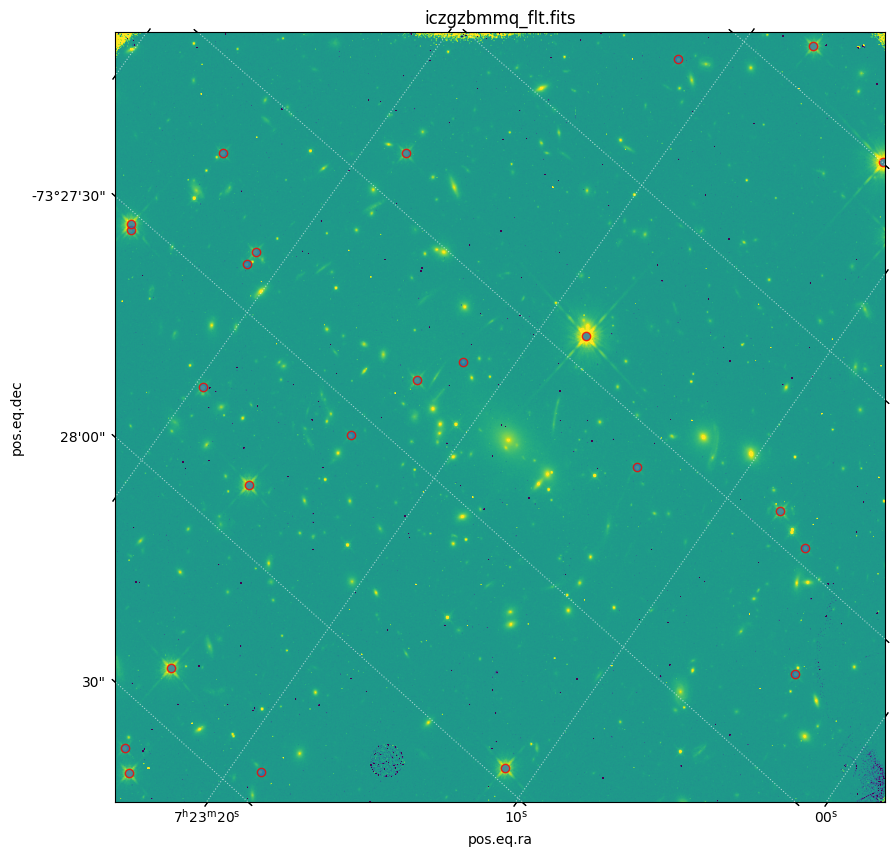

2023238191331 INFO src=drizzlepac.haputils.astrometric_utils- Created catalog 'ref_cat.ecsv' with 38  sources
2023238191331 INFO src=drizzlepac.align- Wrote reference catalog refcatalog.cat.


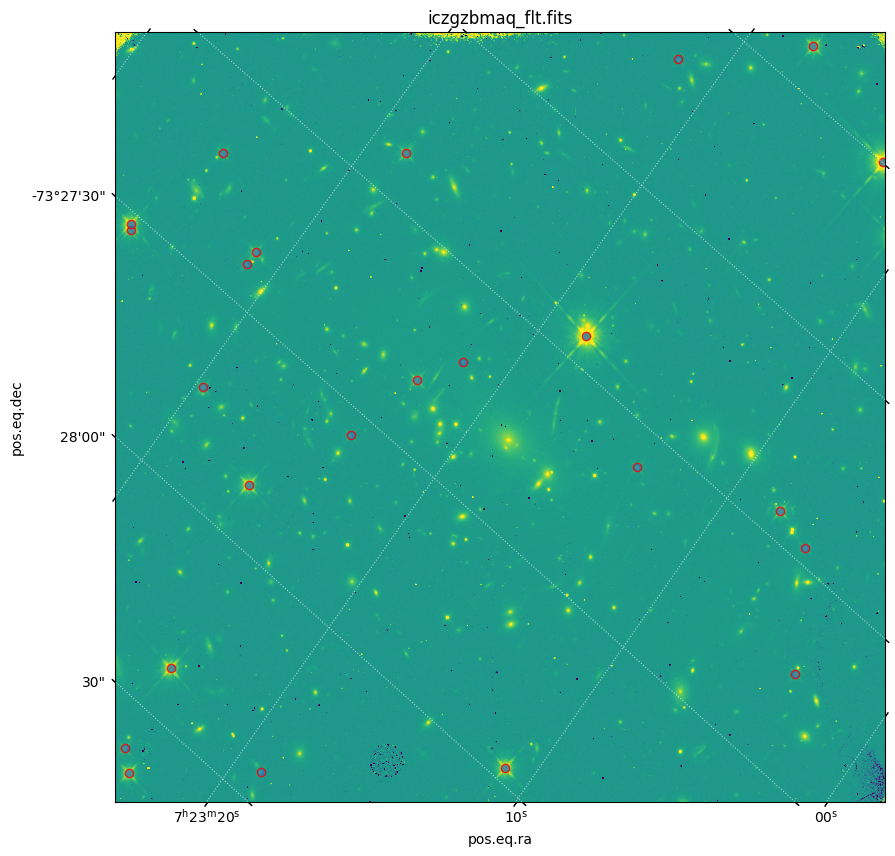

2023238191332 INFO src=drizzlepac.haputils.astrometric_utils- Created catalog 'ref_cat.ecsv' with 38  sources
2023238191332 INFO src=drizzlepac.align- Wrote reference catalog refcatalog.cat.


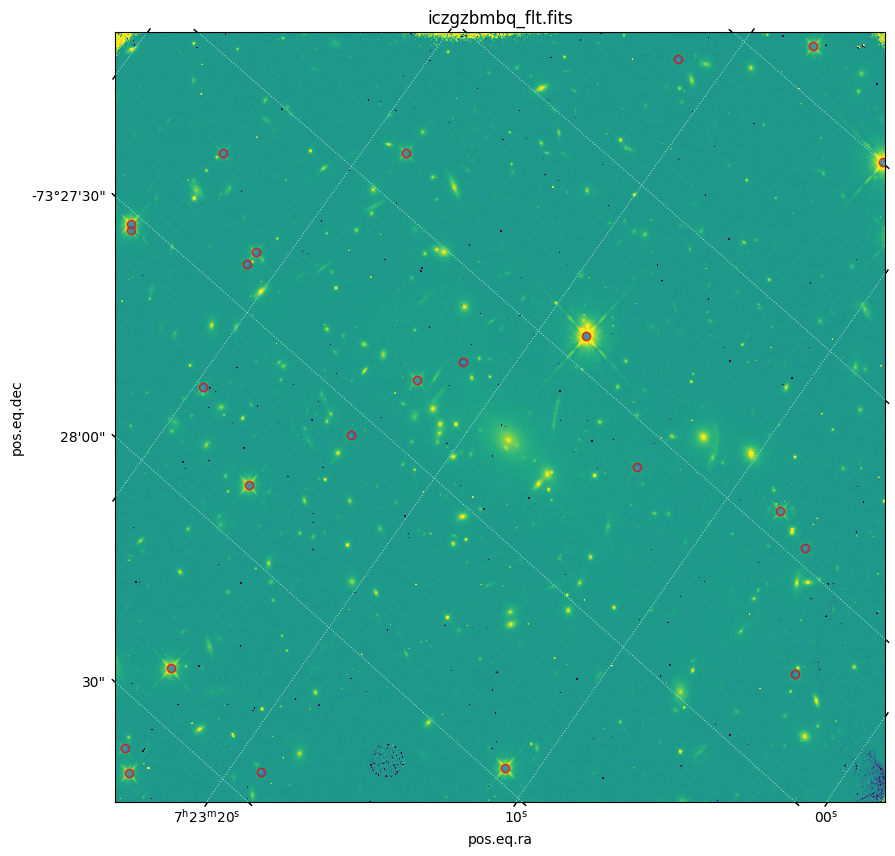

2023238191333 INFO src=drizzlepac.haputils.astrometric_utils- Created catalog 'ref_cat.ecsv' with 38  sources
2023238191333 INFO src=drizzlepac.align- Wrote reference catalog refcatalog.cat.


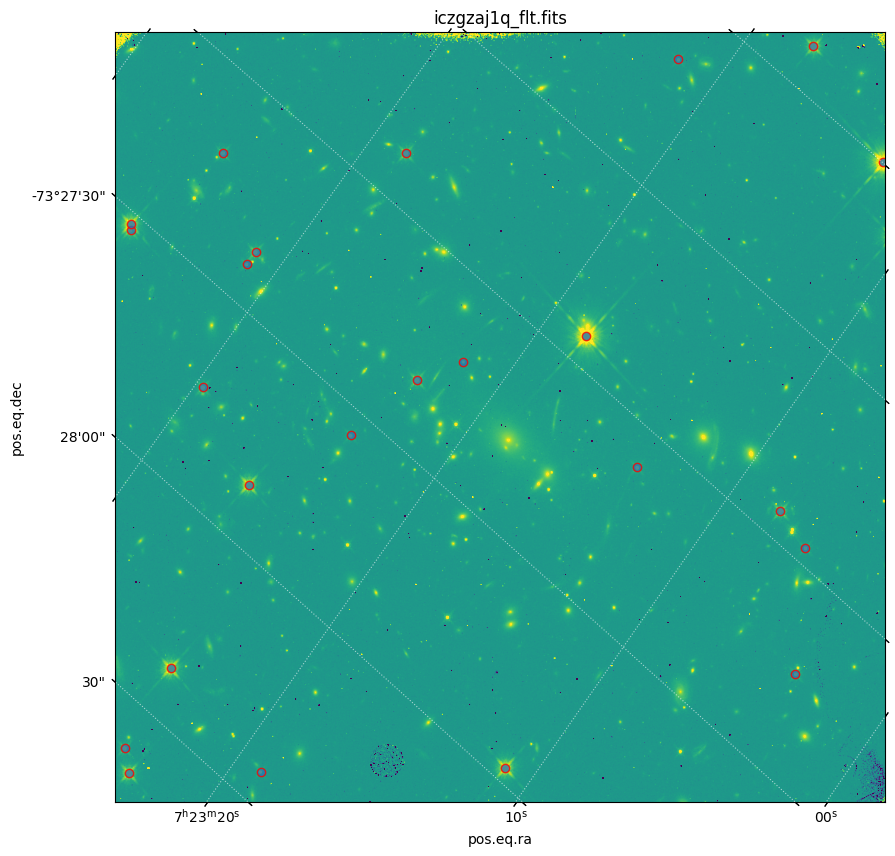

2023238191334 INFO src=drizzlepac.haputils.astrometric_utils- Created catalog 'ref_cat.ecsv' with 38  sources
2023238191334 INFO src=drizzlepac.align- Wrote reference catalog refcatalog.cat.


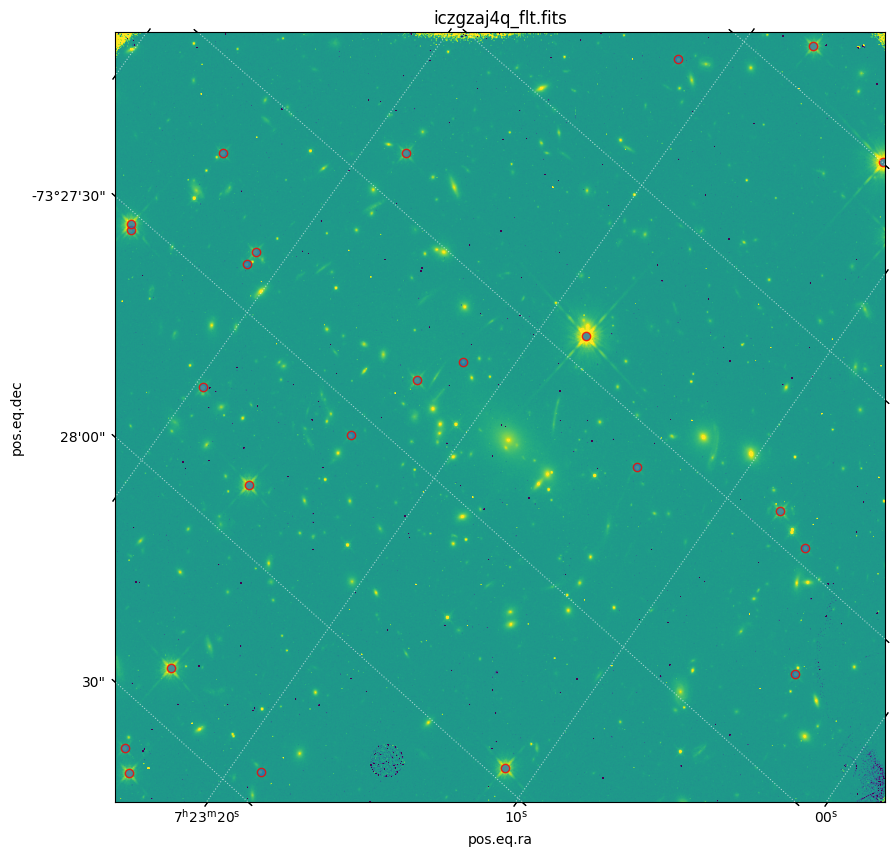

2023238191335 INFO src=drizzlepac.haputils.astrometric_utils- Created catalog 'ref_cat.ecsv' with 38  sources
2023238191335 INFO src=drizzlepac.align- Wrote reference catalog refcatalog.cat.


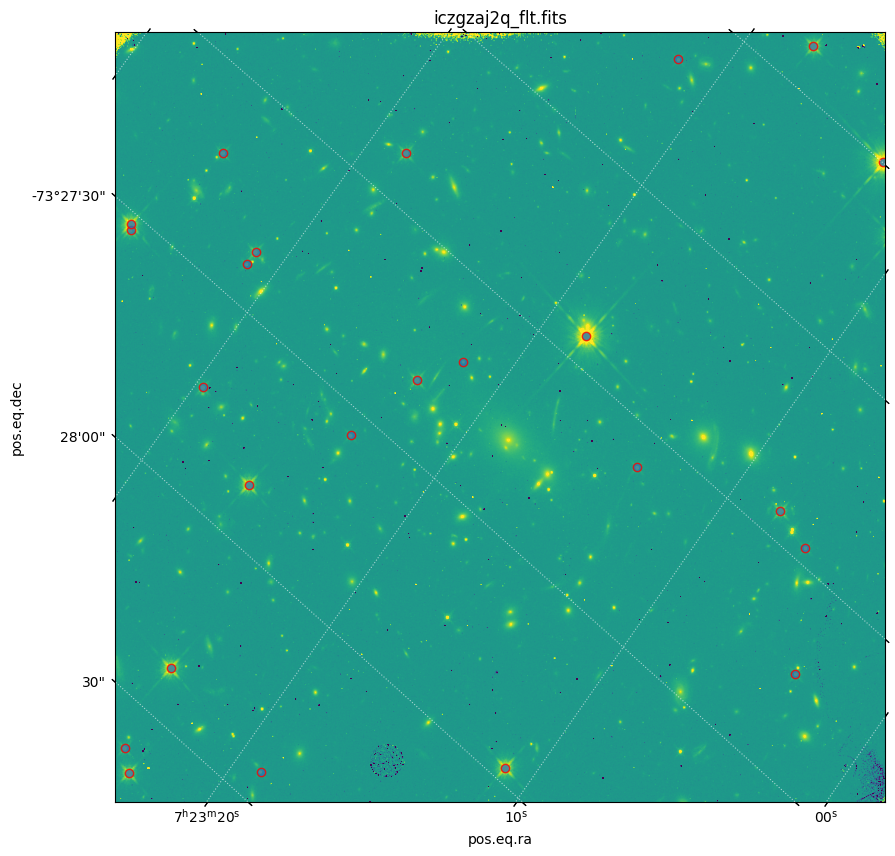

2023238191336 INFO src=drizzlepac.haputils.astrometric_utils- Created catalog 'ref_cat.ecsv' with 38  sources
2023238191336 INFO src=drizzlepac.align- Wrote reference catalog refcatalog.cat.


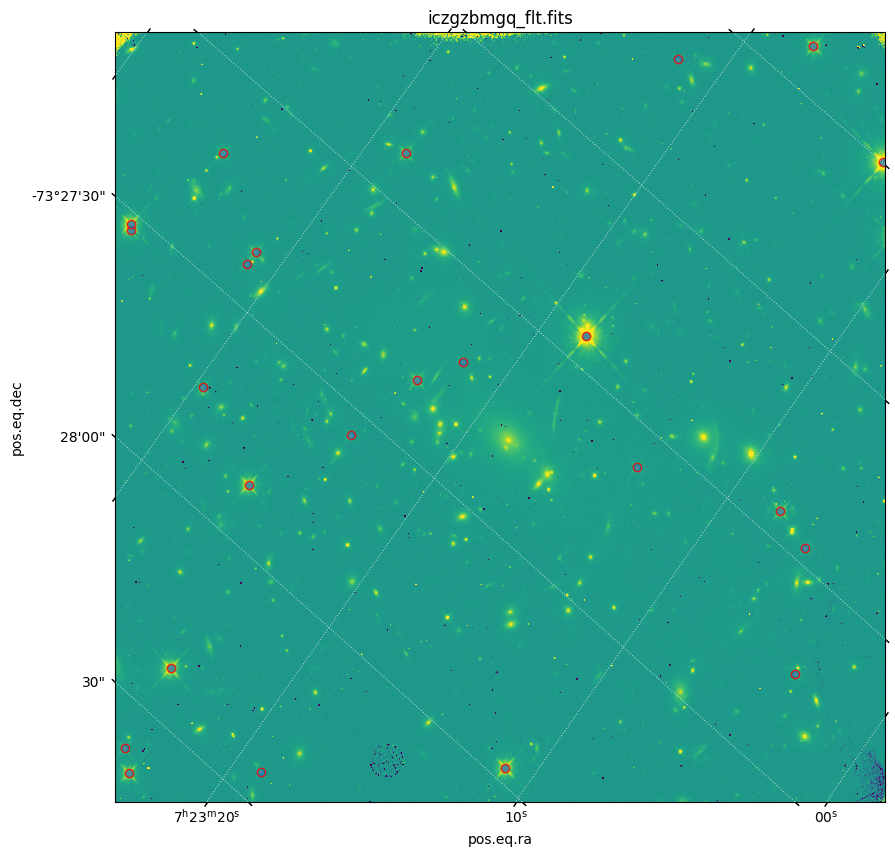

In [32]:
for p in paths:
    fig = plt.figure(figsize=(20, 10))
    ast_tbl = generate_astrometric_catalog(p, output=True) 
    ast_tbl

    hdu = fits.open(filename)
    w = WCS(hdu['SCI',1].header, hdu)
    data = hdu['SCI',1].data
    x, y = w.all_world2pix(np.array([ast_tbl['RA'], ast_tbl['DEC']]).T, 0).T
    
    ax = plt.subplot(projection=w) # matplotlib has support for axes using WCS projections!

    ax.imshow(data, origin='lower',
              norm=ImageNormalize(data, interval=PercentileInterval(99.65), stretch=LogStretch()))
    ax.set_title(os.path.split(p)[-1])
    ax.coords.grid(True, color='white', ls=':', alpha=.6)
    ax.autoscale(False)
    ax.scatter(x, y, edgecolors='r', facecolor=None, alpha=.8)
    plt.show()

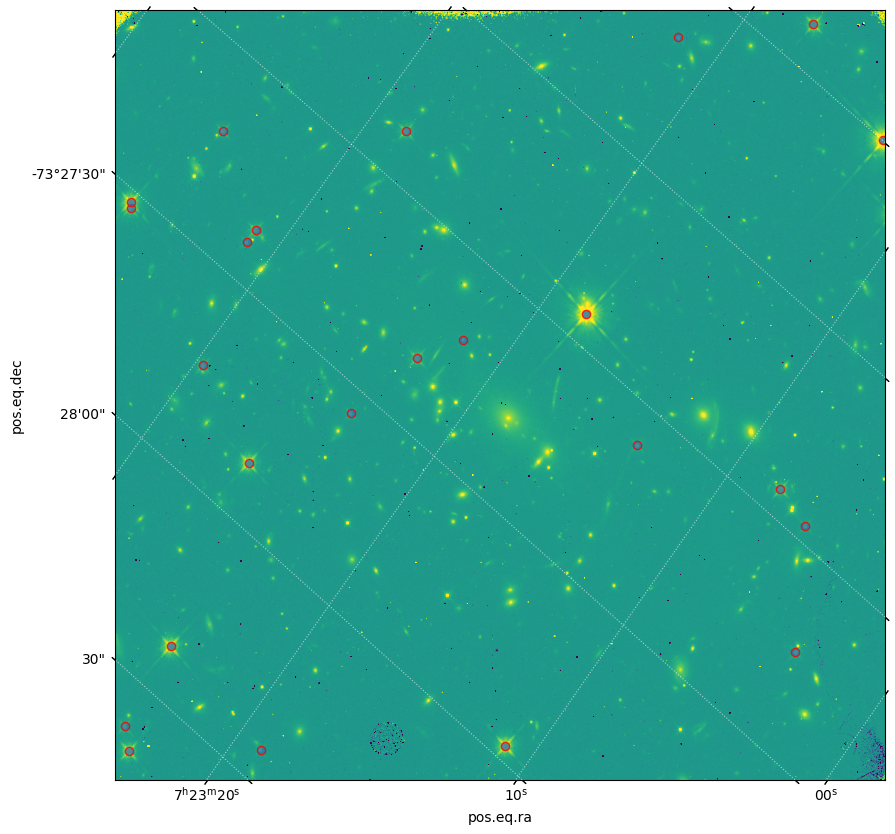